# AgroLab AI — Análise Exploratória de Dados (EDA)
## Morango `San Andreas` · Cultivo protegido semi-hidropônico

**Projeto:** Iniciação Científica — AgroLab AI  
**Cultura:** *Fragaria × ananassa* Duch., cultivar `San Andreas`  
**Recorte territorial:** região de Bragança Paulista / Atibaia (SP)  
**Base analisada:** 365 registros diários sintéticos, ancorados em um recorte meteorológico regional  

### Pergunta de pesquisa

> Um conjunto de sensores ambientais e de fertirrigação contém sinal suficiente para recomendar ações de manejo no morangueiro e sustentar, de forma defensável, a escolha de um sistema protegido semi-hidropônico para o AgroLab AI?

### Hipótese operacional

O sistema semi-hidropônico protegido não é tratado aqui como garantia automática de maior produtividade. A hipótese testável é mais específica: ele oferece **mais variáveis diretamente observáveis e acionáveis** (pH, N, P, K, temperatura e umidade do substrato, microclima), portanto é especialmente adequado a automação, rastreabilidade e apoio à decisão por IA.

---

## ⚠️ Aviso metodológico — leia antes dos gráficos

Esta análise separa três camadas de evidência:

1. **Meteorologia observada:** `dados-temp.csv` contém medições horárias de um curto período regional.
2. **Série anual simulada:** `agrolab_morango_dataset.csv` expande a sazonalidade para 365 dias e simula sensores por regras agronômicas.
3. **Rótulo de ação:** `acao_label` foi produzido pelas mesmas regras de manejo que o modelo tentará recuperar.

Consequências:

- os gráficos verificam **integridade, coerência física e aprendibilidade do simulador**;
- o baseline mede a capacidade de recuperar regras, não eficácia agronômica em campo;
- não é válido usar a acurácia para alegar ganho de produtividade, qualidade ou superioridade causal;
- a região de Bragança Paulista/Atibaia contextualiza o clima, mas a série anual sintética **não equivale** a uma estação oficial completa de Bragança;
- `San Andreas` é um estudo de caso varietal plausível, não uma variável medida no CSV.

Essa delimitação evita *data leakage* conceitual e afirmações maiores do que os dados permitem.

## Por que `San Andreas`?

`San Andreas` é uma cultivar de dias neutros utilizada no Brasil e compatível com cultivo protegido e fora do solo. Em ensaio brasileiro recente com seis cultivares em sistema semi-hidropônico, apresentou os maiores valores de frutos comerciais e produção total/comercial por planta. A escolha é também coerente com publicações técnicas brasileiras que a descrevem em sistemas protegidos e semi-hidropônicos.

**Importante:** o dataset não contém ensaio comparativo de cultivares. Assim, a cultivar serve para **delimitar o caso agronômico**, e não para atribuir a ela o desempenho do modelo.

Fontes principais: [Pesquisa Agropecuária Brasileira, 2024](https://doi.org/10.1590/S1678-3921.pab2024.v59.03384); [Embrapa — Produção de morango fora do solo](https://www.infoteca.cnptia.embrapa.br/infoteca/bitstream/doc/1048342/1/Documento410.pdf); [Epagri — avaliação de cultivares](https://sistemas.epagri.sc.gov.br/semob/consulta.action?cdDoc=59652&subFuncao=consultaPublicacoesDetalhe).

## Parte 1 — Configuração, caminhos e carga dos dados

In [5]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams.update({'figure.figsize': (12, 5), 'axes.titlesize': 13, 'axes.labelsize': 11})

def localizar_pasta_morango():
    candidatos = [Path.cwd(), Path.cwd() / 'data/raw/morango']
    candidatos += [p / 'data/raw/morango' for p in Path.cwd().parents]
    for pasta in candidatos:
        if (pasta / 'agrolab_morango_dataset.csv').exists():
            return pasta.resolve()
    raise FileNotFoundError('Não encontrei data/raw/morango/agrolab_morango_dataset.csv')

PASTA = localizar_pasta_morango()
ARQ_ANUAL = PASTA / 'semi_hidro' / 'agrolab_morango_dataset.csv'
ARQ_METEO = PASTA / 'clima' / 'dados-temp.csv'
PASTA_GRAFICOS = PASTA / 'graficos'
PASTA_GRAFICOS.mkdir(parents=True, exist_ok=True)

def salvar_grafico(nome, figura=None):
    """Salva cada visualização na pasta única de gráficos e a mantém visível no notebook."""
    figura = figura or plt.gcf()
    destino = PASTA_GRAFICOS / f'{nome}.png'
    figura.savefig(destino, dpi=180, bbox_inches='tight', facecolor=figura.get_facecolor())
    print(f'Gráfico salvo em: {destino.relative_to(PASTA)}')

print('Pasta de dados:', PASTA)
print('Dataset principal:', ARQ_ANUAL.relative_to(PASTA))
print('Dados meteorológicos:', ARQ_METEO.relative_to(PASTA))
print('Saída dos gráficos:', PASTA_GRAFICOS.relative_to(PASTA))

Pasta de dados: C:\Users\Magora\Desktop\IC\ic-agro-lab\data\raw\morango
Dataset principal: semi_hidro\agrolab_morango_dataset.csv
Dados meteorológicos: clima\dados-temp.csv
Saída dos gráficos: graficos


In [6]:
df = pd.read_csv(ARQ_ANUAL, sep=';', decimal=',', encoding='utf-8-sig')
df['data'] = pd.to_datetime(df['data'], errors='raise')

meteo = pd.read_csv(ARQ_METEO, sep=';', decimal=',', encoding='utf-8-sig', na_values=['', ' ', '-9999'])
meteo.columns = meteo.columns.str.strip().str.replace('ï»¿', '', regex=False)

print(f'Série anual: {df.shape[0]} linhas × {df.shape[1]} colunas')
print(f'Meteorologia horária: {meteo.shape[0]} linhas × {meteo.shape[1]} colunas')
display(df.head(3))

Série anual: 365 linhas × 18 colunas
Meteorologia horária: 768 linhas × 19 colunas


,data,temp_ar_media,temp_ar_max,temp_ar_min,umidade_ar_media,radiacao_PAR,chuva_mm,h_calor_extremo,h_umid_alta,pH,N_mgL,P_mgL,K_mgL,temp_substrato,umidade_solo,luminosidade_lux,acao_label,acao_nome
0,2025-01-01,17.7,22.5,13.9,86.2,685.5,2.7,0,6,5.86,187.8,39.6,297.5,15.8,76.8,485.3,0,Ideal
1,2025-01-02,18.3,23.6,13.1,90.1,560.7,4.4,0,8,6.11,187.7,38.1,281.2,16.9,70.2,387.1,0,Ideal
2,2025-01-03,16.6,23.3,12.0,85.2,748.6,0.3,0,4,5.96,181.1,40.9,298.0,15.3,71.8,510.4,0,Ideal


### 1.1 Dicionário das variáveis

| Grupo | Variáveis | Papel |
|---|---|---|
| Tempo | `data` | ordenação e sazonalidade; não entra como número bruto no modelo |
| Microclima | `temp_ar_media`, `temp_ar_max`, `temp_ar_min`, `umidade_ar_media`, `radiacao_PAR`, `chuva_mm`, `h_calor_extremo`, `h_umid_alta` | exposição ambiental e risco térmico/fitossanitário |
| Fertirrigação | `pH`, `N_mgL`, `P_mgL`, `K_mgL` | estado químico simulável e corrigível da solução/substrato |
| Zona radicular | `temp_substrato`, `umidade_solo` | condição do substrato (o nome legado `umidade_solo` significa umidade do substrato nesta base) |
| Luz | `luminosidade_lux` | proxy luminosa derivada da radiação |
| Alvo | `acao_label`, `acao_nome` | ação recomendada pelas regras do simulador |

Classes: `0 = Ideal`, `1 = Travar Irrigação`, `2 = Irrigar`, `3 = Proteger`.

## Parte 2 — Qualidade, integridade e sanidade física

In [7]:
resumo_qualidade = pd.Series({
    'linhas': len(df),
    'colunas': df.shape[1],
    'nulos': int(df.isna().sum().sum()),
    'duplicatas completas': int(df.duplicated().sum()),
    'datas duplicadas': int(df['data'].duplicated().sum()),
    'início': df['data'].min().date(),
    'fim': df['data'].max().date(),
    'dias ausentes no intervalo': len(pd.date_range(df.data.min(), df.data.max()).difference(df.data)),
})
display(resumo_qualidade.to_frame('resultado'))

,resultado
linhas,365
colunas,18
nulos,0
duplicatas completas,0
datas duplicadas,0
início,2025-01-01
fim,2025-12-31
dias ausentes no intervalo,0


In [8]:
checagens = pd.Series({
    'temp_min <= temp_media <= temp_max': ((df.temp_ar_min <= df.temp_ar_media) & (df.temp_ar_media <= df.temp_ar_max)).all(),
    'pH fisicamente possível (0–14)': df.pH.between(0, 14).all(),
    'umidade do ar em 0–100%': df.umidade_ar_media.between(0, 100).all(),
    'umidade do substrato em 0–100%': df.umidade_solo.between(0, 100).all(),
    'chuva não negativa': df.chuva_mm.ge(0).all(),
    'N, P e K não negativos': df[['N_mgL','P_mgL','K_mgL']].ge(0).all().all(),
    'rótulos limitados a 0,1,2,3': set(df.acao_label.unique()).issubset({0,1,2,3}),
})
display(checagens.rename('válido').to_frame())
assert checagens.all(), 'Há violação de sanidade; revise o gerador antes de modelar.'

,válido
temp_min <= temp_media <= temp_max,True
pH fisicamente possível (0–14),True
umidade do ar em 0–100%,True
umidade do substrato em 0–100%,True
chuva não negativa,True
"N, P e K não negativos",True
"rótulos limitados a 0,1,2,3",True


### 2.1 Coerência entre códigos e nomes

Um código não pode apontar para dois nomes diferentes. Essa checagem detecta contradições no alvo antes do treinamento.

In [9]:
mapa_classes = (df.groupby('acao_label')['acao_nome']
                  .agg(['nunique', lambda s: ', '.join(sorted(s.unique()))])
                  .rename(columns={'<lambda_0>': 'nomes'}))
display(mapa_classes)
assert mapa_classes['nunique'].eq(1).all()

,nunique,nomes
acao_label,,
0,1,Ideal
1,1,Travar Irrigação
2,1,Irrigar
3,1,Proteger


## Parte 3 — Balanceamento das ações

Gráfico salvo em: graficos\01_balanceamento_acoes.png


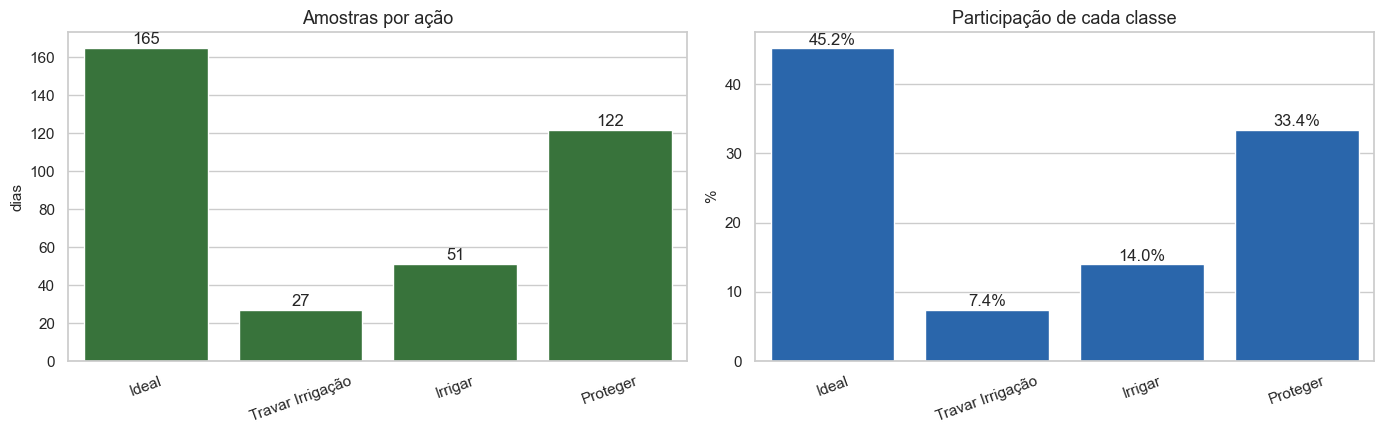

,n,%
acao_nome,,
Ideal,165,45.2
Travar Irrigação,27,7.4
Irrigar,51,14.0
Proteger,122,33.4


In [10]:
ordem = ['Ideal', 'Travar Irrigação', 'Irrigar', 'Proteger']
cont = df.acao_nome.value_counts().reindex(ordem, fill_value=0)
pct = 100 * cont / len(df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(x=cont.index, y=cont.values, ax=axes[0], color='#2e7d32')
axes[0].set(title='Amostras por ação', xlabel='', ylabel='dias'); axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(cont): axes[0].text(i, v + 2, str(v), ha='center')
sns.barplot(x=pct.index, y=pct.values, ax=axes[1], color='#1565c0')
axes[1].set(title='Participação de cada classe', xlabel='', ylabel='%'); axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(pct): axes[1].text(i, v + .5, f'{v:.1f}%', ha='center')
plt.tight_layout(); salvar_grafico('01_balanceamento_acoes', fig); plt.show()
display(pd.DataFrame({'n': cont, '%': pct.round(1)}))

### 3.1 Interpretação

O conjunto é desbalanceado, algo plausível em manejo: condições ideais devem ser comuns e eventos críticos menos frequentes. Por isso, a avaliação posterior prioriza **F1 macro**, divisão estratificada e `class_weight='balanced_subsample'`, em vez de confiar apenas em acurácia.

## Parte 4 — Distribuições e cobertura dos limites operacionais

Gráfico salvo em: graficos\02_distribuicoes_limites.png


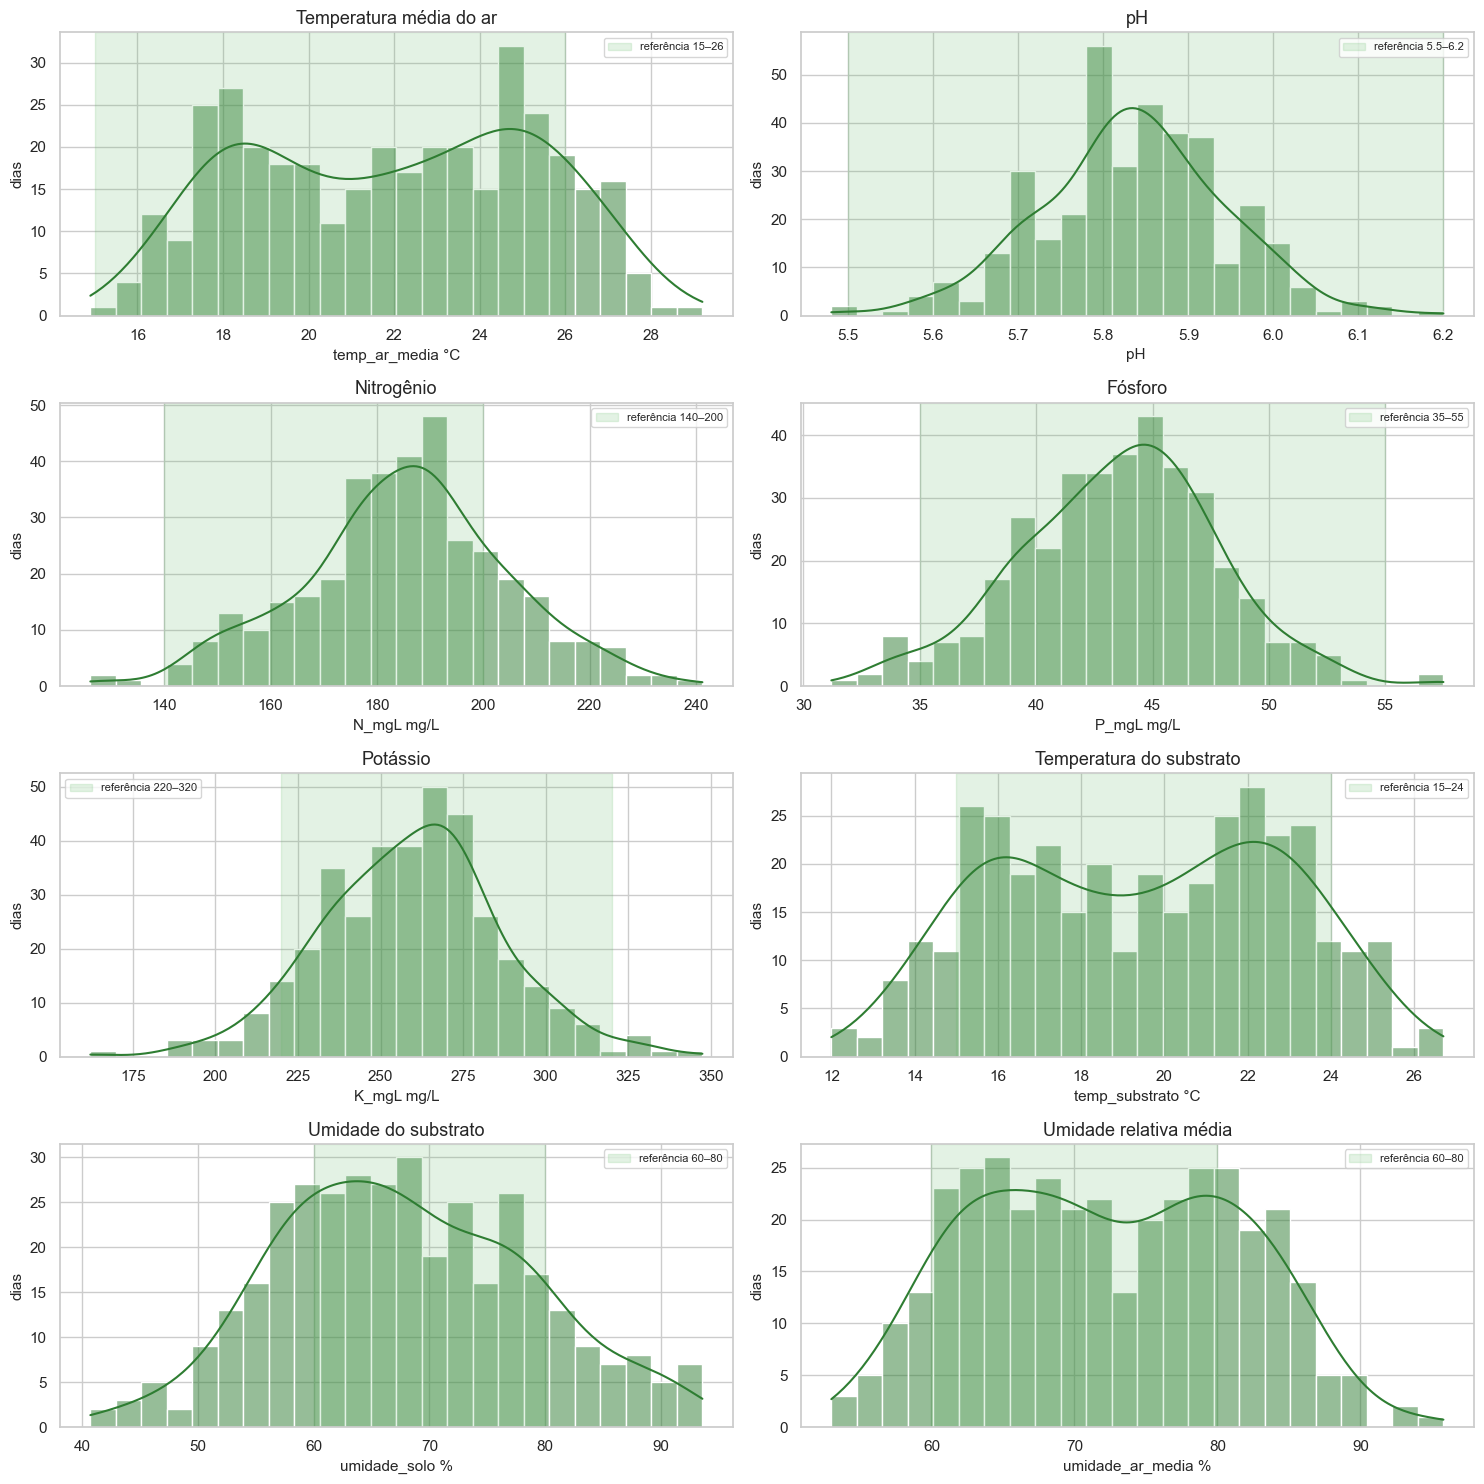

In [11]:
faixas = [
    ('temp_ar_media', 'Temperatura média do ar', (15, 26), '°C'),
    ('pH', 'pH', (5.5, 6.2), ''),
    ('N_mgL', 'Nitrogênio', (140, 200), 'mg/L'),
    ('P_mgL', 'Fósforo', (35, 55), 'mg/L'),
    ('K_mgL', 'Potássio', (220, 320), 'mg/L'),
    ('temp_substrato', 'Temperatura do substrato', (15, 24), '°C'),
    ('umidade_solo', 'Umidade do substrato', (60, 80), '%'),
    ('umidade_ar_media', 'Umidade relativa média', (60, 80), '%'),
]
fig, axes = plt.subplots(4, 2, figsize=(15, 15))
for ax, (col, titulo, ideal, unidade) in zip(axes.flat, faixas):
    sns.histplot(df[col], bins=24, kde=True, ax=ax, color='#2e7d32')
    ax.axvspan(*ideal, color='#66bb6a', alpha=.18, label=f'referência {ideal[0]}–{ideal[1]}')
    ax.set(title=titulo, xlabel=f'{col} {unidade}', ylabel='dias'); ax.legend(fontsize=8)
plt.tight_layout(); salvar_grafico('02_distribuicoes_limites', fig); plt.show()

### 4.1 Como ler

As faixas sombreadas são **limites operacionais adotados pelo simulador**, úteis para auditar sua cobertura. Não devem ser tratadas como receitas universais: cultivar, fase fenológica, composição da solução, tipo de substrato e manejo alteram os alvos. Caudas fora da faixa são necessárias para que existam exemplos de intervenção.

## Parte 5 — Microclima de Bragança/Atibaia e sazonalidade

Gráfico salvo em: graficos\03_sazonalidade_climatica.png


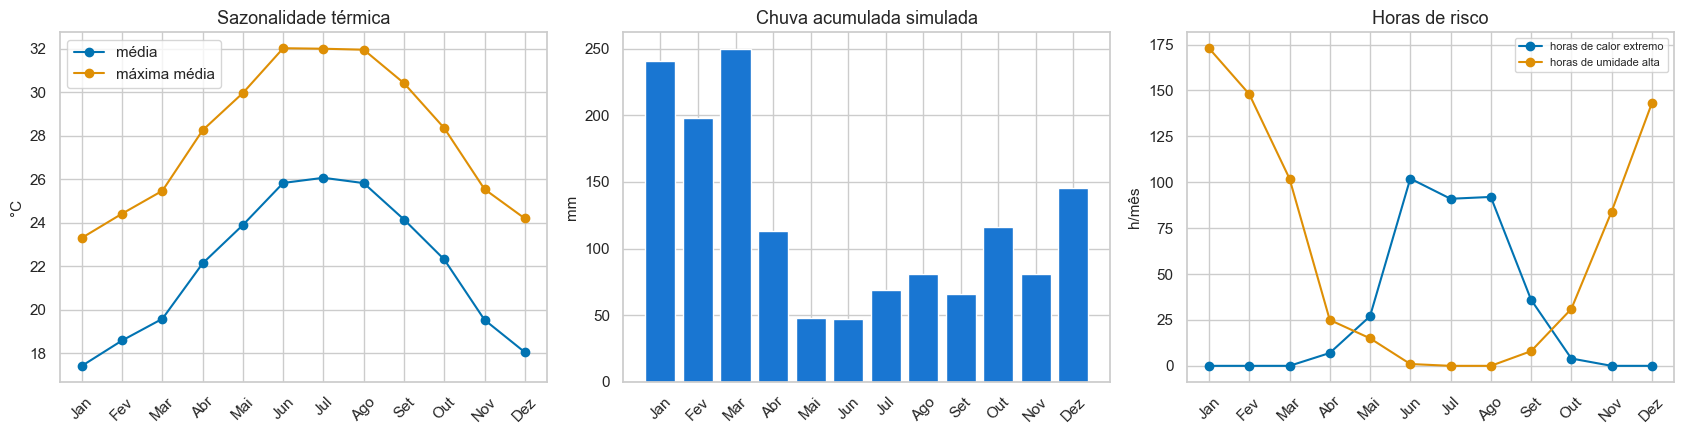

In [12]:
df['mes'] = df.data.dt.month
meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
mensal = df.groupby('mes').agg(
    temp_media=('temp_ar_media','mean'), temp_max=('temp_ar_max','mean'),
    umidade=('umidade_ar_media','mean'), chuva=('chuva_mm','sum'),
    calor=('h_calor_extremo','sum'), umid_alta=('h_umid_alta','sum'))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
axes[0].plot(meses, mensal.temp_media, marker='o', label='média')
axes[0].plot(meses, mensal.temp_max, marker='o', label='máxima média'); axes[0].set(title='Sazonalidade térmica', ylabel='°C'); axes[0].legend()
axes[1].bar(meses, mensal.chuva, color='#1976d2'); axes[1].set(title='Chuva acumulada simulada', ylabel='mm')
axes[2].plot(meses, mensal.calor, marker='o', label='horas de calor extremo')
axes[2].plot(meses, mensal.umid_alta, marker='o', label='horas de umidade alta'); axes[2].set(title='Horas de risco', ylabel='h/mês'); axes[2].legend(fontsize=8)
for ax in axes: ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); salvar_grafico('03_sazonalidade_climatica', fig); plt.show()

Gráfico salvo em: graficos\04_acoes_por_mes.png


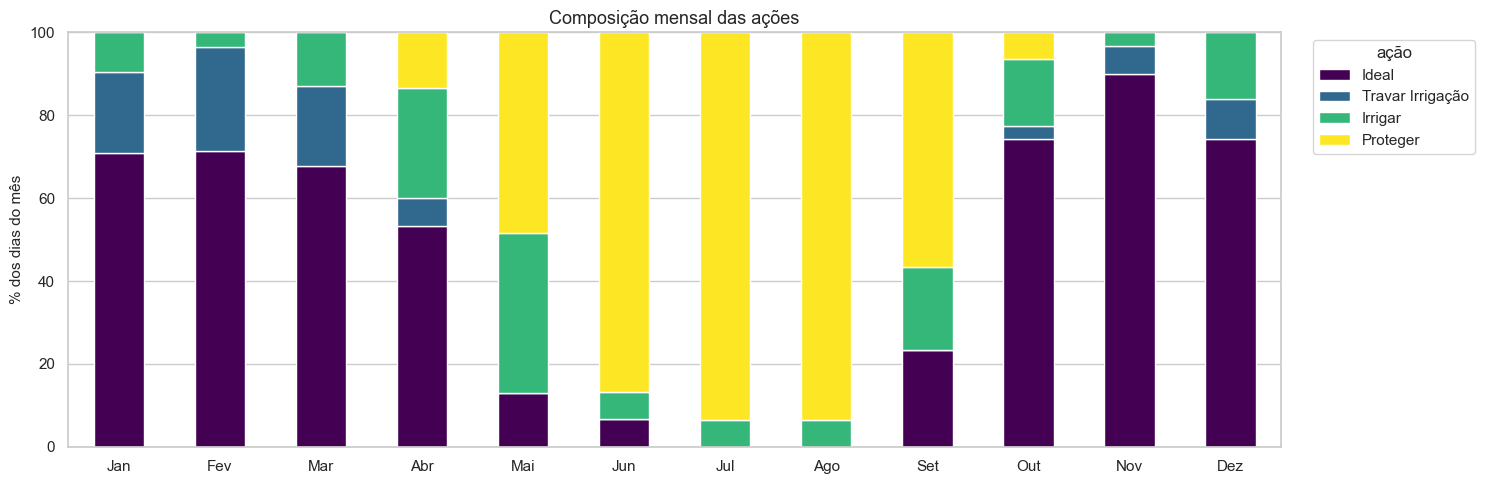

In [13]:
acao_mes = pd.crosstab(df.mes, df.acao_nome, normalize='index').reindex(columns=ordem, fill_value=0) * 100
acao_mes.index = meses
acao_mes.plot(kind='bar', stacked=True, figsize=(15,5), colormap='viridis')
plt.title('Composição mensal das ações'); plt.xlabel(''); plt.ylabel('% dos dias do mês')
plt.legend(title='ação', bbox_to_anchor=(1.02, 1)); plt.xticks(rotation=0); plt.tight_layout(); salvar_grafico('04_acoes_por_mes'); plt.show()

### 5.1 Interpretação

A sazonalidade é relevante porque o morangueiro responde ao regime térmico e ao fotoperíodo, e `San Andreas` é uma cultivar de dias neutros — categoria que permite produção mais distribuída, embora não elimine a influência do clima. Aqui, a curva anual é gerada por funções sazonais; portanto, ela demonstra o comportamento esperado do **simulador**, não reconstrói um ano meteorológico observado.

## Parte 6 — Relações físicas e agronômicas programadas

Gráfico salvo em: graficos\05_relacoes_fisicas.png


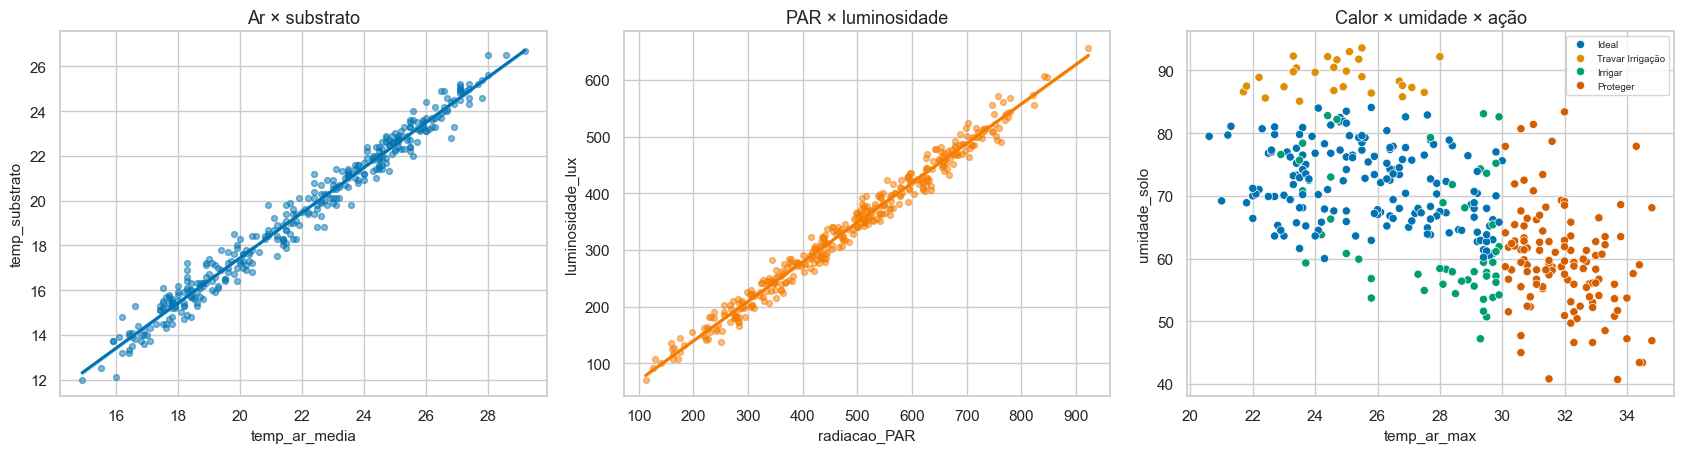

,x,y,correlação de Pearson
0,temp_ar_media,temp_substrato,0.989
1,radiacao_PAR,luminosidade_lux,0.991
2,chuva_mm,umidade_solo,0.651


In [14]:
amostra = df.sample(min(365, len(df)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.7))
sns.regplot(data=amostra, x='temp_ar_media', y='temp_substrato', scatter_kws={'s':18,'alpha':.5}, ax=axes[0])
axes[0].set_title('Ar × substrato')
sns.regplot(data=amostra, x='radiacao_PAR', y='luminosidade_lux', scatter_kws={'s':18,'alpha':.5}, ax=axes[1], color='#f57c00')
axes[1].set_title('PAR × luminosidade')
sns.scatterplot(data=amostra, x='temp_ar_max', y='umidade_solo', hue='acao_nome', hue_order=ordem, ax=axes[2], s=35)
axes[2].set_title('Calor × umidade × ação'); axes[2].legend(fontsize=7)
plt.tight_layout(); salvar_grafico('05_relacoes_fisicas', fig); plt.show()

pares = [('temp_ar_media','temp_substrato'), ('radiacao_PAR','luminosidade_lux'), ('chuva_mm','umidade_solo')]
display(pd.DataFrame([{'x':a, 'y':b, 'correlação de Pearson':df[a].corr(df[b])} for a,b in pares]).round(3))

### 6.1 Interpretação

- **Ar × substrato:** o acoplamento verifica que a zona radicular responde ao ambiente com amortecimento.
- **PAR × luminosidade:** correlação alta é esperada porque ambas representam luz e foram acopladas no gerador; mantê-las juntas pode criar redundância.
- **Calor × umidade:** permite observar regiões onde regras distintas competem; essa sobreposição torna a prioridade das regras parte do problema.

Essas relações validam a coerência interna do gerador, não substituem calibração com sensores reais.

## Parte 7 — Correlações e redundância

Gráfico salvo em: graficos\06_mapa_correlacoes.png


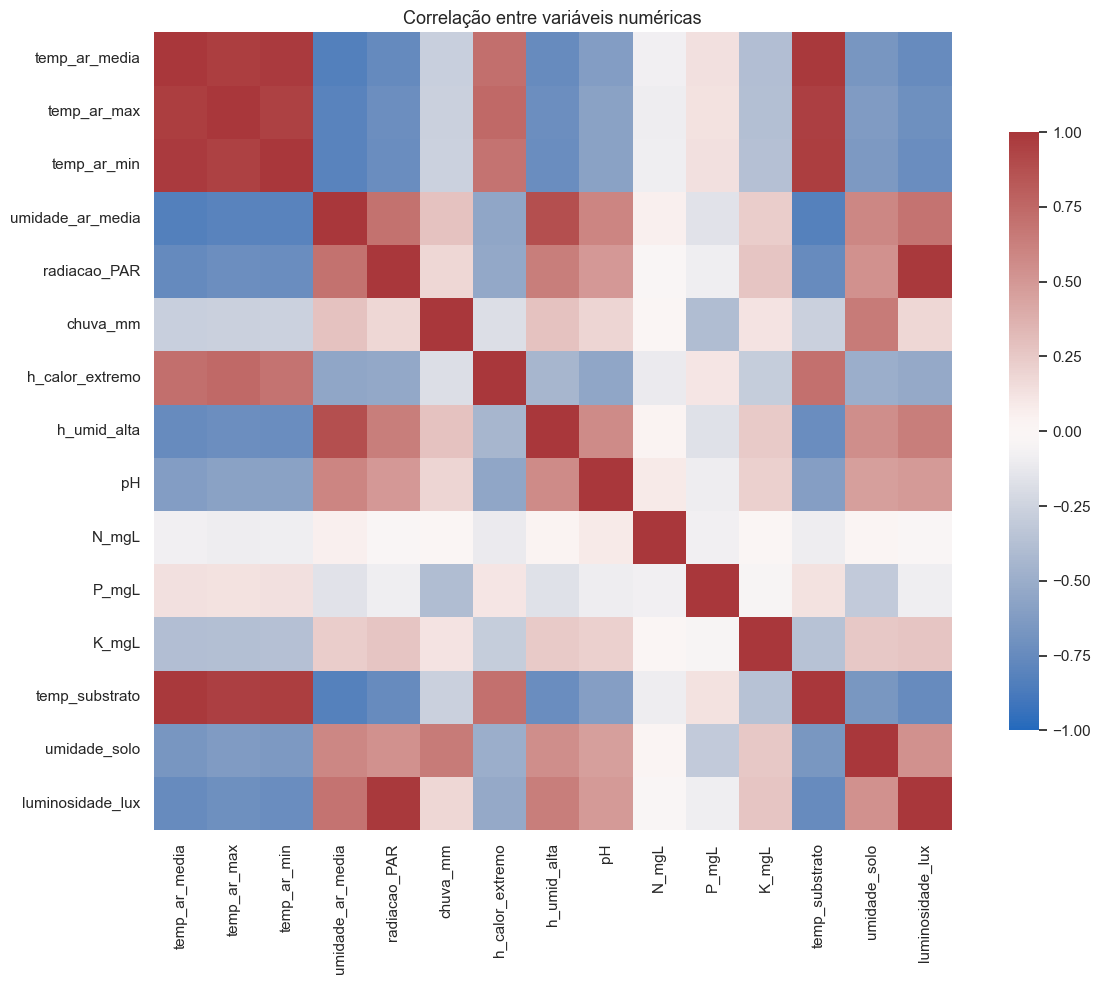

,level_0,level_1,r
74,radiacao_PAR,luminosidade_lux,0.991
12,temp_ar_media,temp_substrato,0.989
2,temp_ar_media,temp_ar_min,0.977
1,temp_ar_media,temp_ar_max,0.967
42,temp_ar_min,temp_substrato,0.967
27,temp_ar_max,temp_substrato,0.956
17,temp_ar_max,temp_ar_min,0.945
52,umidade_ar_media,h_umid_alta,0.882
3,temp_ar_media,umidade_ar_media,-0.830
57,umidade_ar_media,temp_substrato,-0.823


In [15]:
features_num = [c for c in df.select_dtypes('number').columns if c not in ['acao_label','mes']]
corr = df[features_num].corr()
plt.figure(figsize=(13,10))
sns.heatmap(corr, cmap='vlag', center=0, vmin=-1, vmax=1, square=True, cbar_kws={'shrink':.75})
plt.title('Correlação entre variáveis numéricas'); plt.tight_layout(); salvar_grafico('06_mapa_correlacoes'); plt.show()

pares_corr = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
                 .rename('r').reset_index().assign(abs_r=lambda x:x.r.abs())
                 .sort_values('abs_r', ascending=False).head(10))
display(pares_corr.drop(columns='abs_r').round(3))

### 7.1 Alerta de modelagem

Correlações muito altas podem ser fisicamente justificáveis ou consequência direta da geração sintética. Elas não invalidam árvores de decisão, mas tornam a importância por impureza menos confiável: duas variáveis redundantes dividem ou disputam importância. Por isso, o notebook também calcula **importância por permutação** no conjunto de teste.

## Parte 8 — O que dispara cada ação?

,temp_ar_max,h_calor_extremo,h_umid_alta,pH,N_mgL,P_mgL,K_mgL,umidade_solo
acao_nome,,,,,,,,
Ideal,25.700000,0.000000,3.000000,5.860000,187.900000,43.800000,269.100000,71.800000
Travar Irrigação,24.700000,0.000000,4.000000,5.930000,187.700000,41.000000,263.000000,88.900000
Irrigar,28.500000,0.000000,0.000000,5.850000,177.600000,43.600000,255.900000,59.400000
Proteger,31.950000,3.000000,0.000000,5.760000,186.100000,44.400000,249.150000,59.300000


Gráfico salvo em: graficos\07_perfil_das_acoes.png


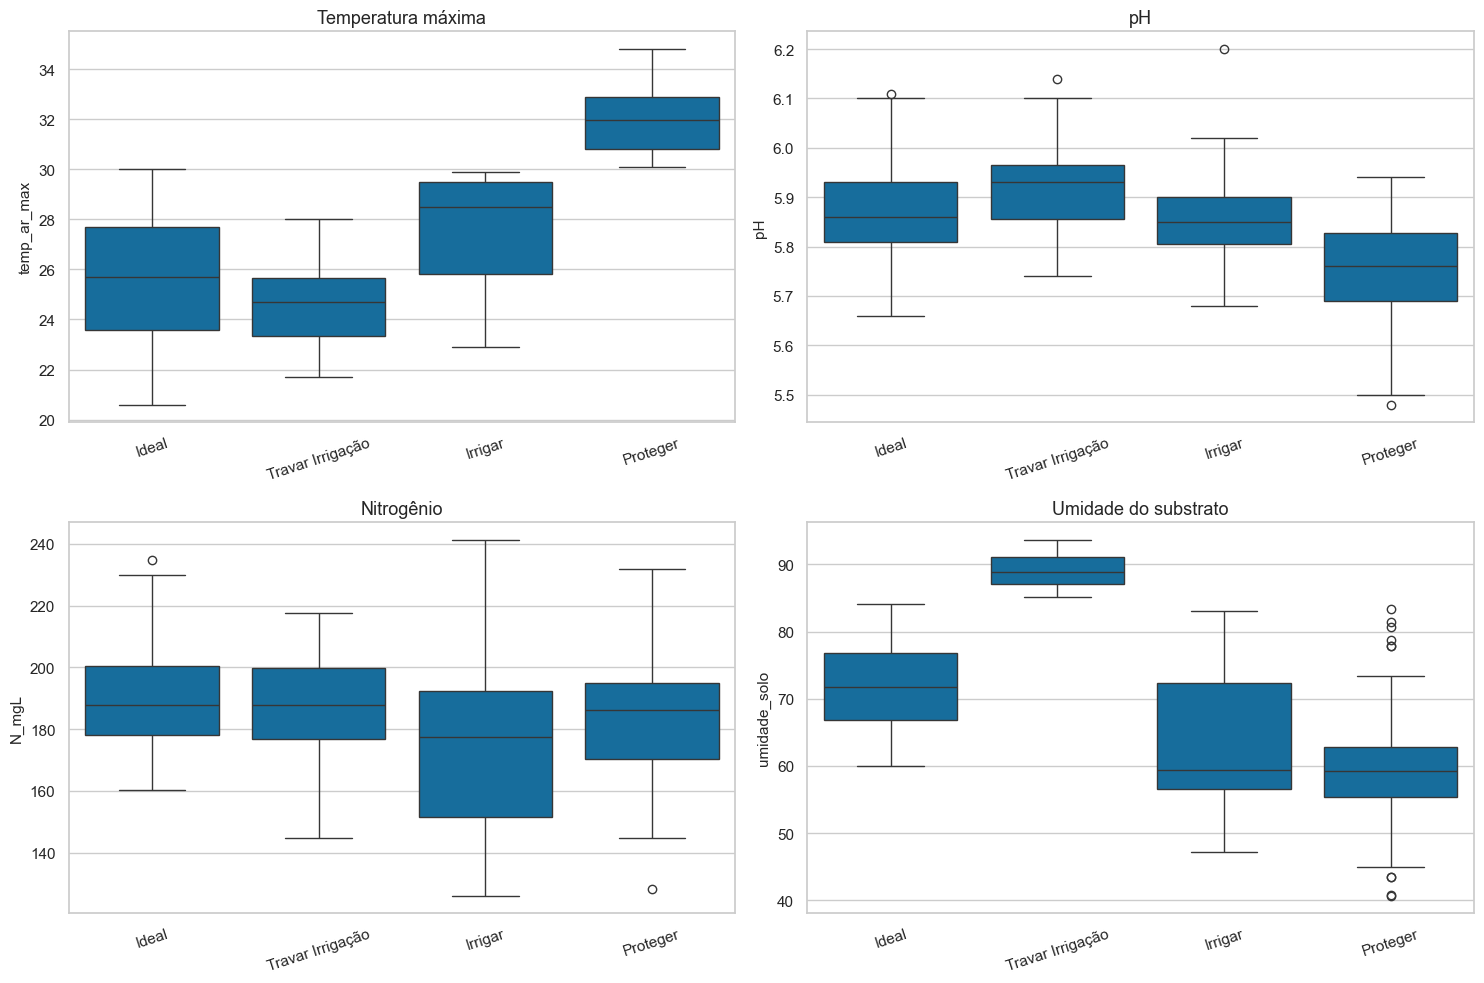

In [16]:
variaveis_chave = ['temp_ar_max','h_calor_extremo','h_umid_alta','pH','N_mgL','P_mgL','K_mgL','umidade_solo']
perfil = df.groupby('acao_nome')[variaveis_chave].median().reindex(ordem)
display(perfil.round(2).style.background_gradient(cmap='YlGnBu', axis=0))

fig, axes = plt.subplots(2, 2, figsize=(15,10))
for ax, col, titulo in zip(axes.flat,
                           ['temp_ar_max','pH','N_mgL','umidade_solo'],
                           ['Temperatura máxima','pH','Nitrogênio','Umidade do substrato']):
    sns.boxplot(data=df, x='acao_nome', y=col, order=ordem, ax=ax)
    ax.set_title(titulo); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=18)
plt.tight_layout(); salvar_grafico('07_perfil_das_acoes', fig); plt.show()

### 8.1 Interpretação

Os perfis revelam se as decisões estão associadas a estados agronomicamente inteligíveis. Como os rótulos são baseados em regras, separações nítidas são esperadas. Se duas ações aparecem sob condições parecidas, isso pode refletir a **ordem de prioridade** do gerador, não ambiguidade observada por especialistas.

## Parte 9 — Engenharia temporal sem vazamento

In [17]:
modelo = df.copy()
modelo['mes_sin'] = np.sin(2*np.pi*modelo.data.dt.month/12)
modelo['mes_cos'] = np.cos(2*np.pi*modelo.data.dt.month/12)

feature_cols = [c for c in df.columns if c not in ['data','acao_label','acao_nome','mes']]
feature_cols += ['mes_sin','mes_cos']
X = modelo[feature_cols]
y = modelo['acao_nome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.25, stratify=y, random_state=RANDOM_STATE)
print('Treino:', X_train.shape, '| Teste:', X_test.shape)
display(pd.DataFrame({'treino': y_train.value_counts(), 'teste': y_test.value_counts()}).fillna(0).astype(int))

Treino: (273, 17) | Teste: (92, 17)


,treino,teste
acao_nome,,
Ideal,124,41
Proteger,91,31
Irrigar,38,13
Travar Irrigação,20,7


O timestamp bruto não entra no modelo: datas absolutas favorecem memorização sem significado transferível. Mês é codificado em seno/cosseno para preservar a circularidade entre dezembro e janeiro. A divisão é estratificada, mas aleatória; para implantação real, o teste correto deve ser **temporal e externo**, idealmente em outro ciclo de cultivo.

## Parte 10 — O dataset é aprendível? Baseline Random Forest

                  precision    recall  f1-score   support

           Ideal      0.870     0.976     0.920        41
         Irrigar      0.875     0.538     0.667        13
        Proteger      1.000     1.000     1.000        31
Travar Irrigação      1.000     1.000     1.000         7

        accuracy                          0.924        92
       macro avg      0.936     0.879     0.897        92
    weighted avg      0.924     0.924     0.917        92

F1 macro: 0.897
Gráfico salvo em: graficos\08_matriz_confusao.png


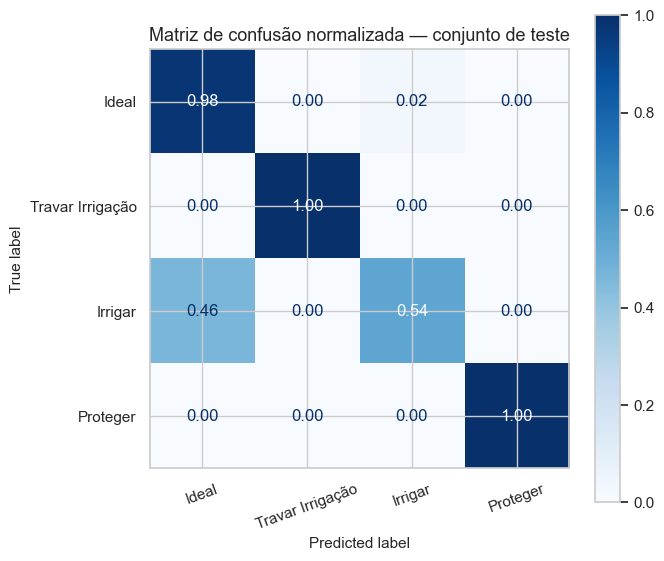

In [18]:
rf = RandomForestClassifier(
    n_estimators=500, min_samples_leaf=2,
    class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

print(classification_report(y_test, pred, digits=3, zero_division=0))
print('F1 macro:', round(f1_score(y_test, pred, average='macro'), 3))

fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=ordem, normalize='true', cmap='Blues', values_format='.2f', ax=ax)
ax.set_title('Matriz de confusão normalizada — conjunto de teste')
plt.xticks(rotation=20); plt.tight_layout(); salvar_grafico('08_matriz_confusao', fig); plt.show()

### 10.1 O resultado significa — e o que não significa

Desempenho alto indica que as features carregam o sinal necessário para recuperar os rótulos do simulador. Não prova que a recomendação funciona na lavoura, porque features e alvos compartilham a mesma origem mecanística. O próximo salto de validade exige dados independentes: sensores calibrados, registro das intervenções e desfechos de planta/fruto.

## Parte 11 — Quais sensores carregam sinal?

Gráfico salvo em: graficos\09_importancia_variaveis.png


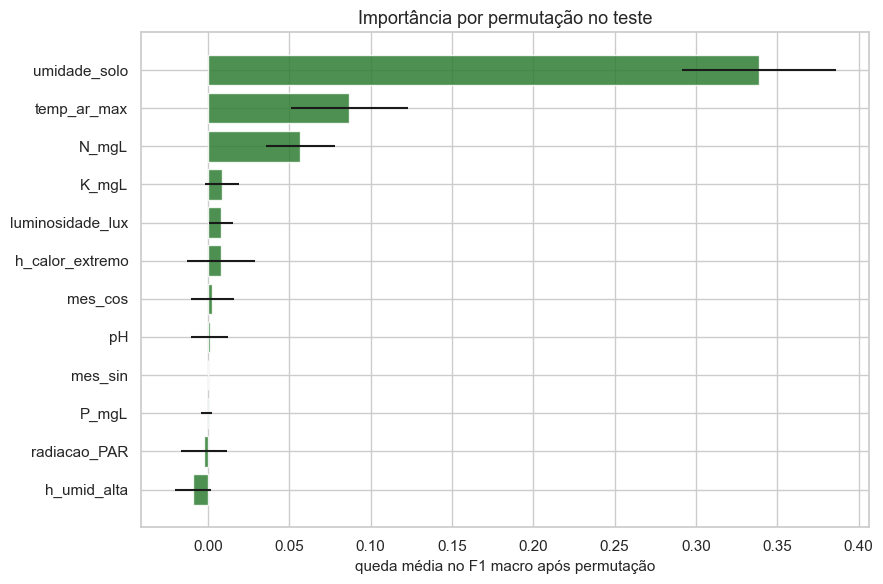

,variável,queda_F1,desvio
13,umidade_solo,0.3387,0.0471
1,temp_ar_max,0.0869,0.0358
9,N_mgL,0.0568,0.0212
11,K_mgL,0.0085,0.0106
14,luminosidade_lux,0.0082,0.0073
6,h_calor_extremo,0.0080,0.0211
16,mes_cos,0.0026,0.0133
8,pH,0.0010,0.0111
15,mes_sin,0.0000,0.0000
10,P_mgL,-0.0007,0.0035


In [19]:
perm = permutation_importance(rf, X_test, y_test, scoring='f1_macro', n_repeats=25, random_state=RANDOM_STATE, n_jobs=-1)
imp = (pd.DataFrame({'variável': X_test.columns, 'queda_F1': perm.importances_mean, 'desvio': perm.importances_std})
         .sort_values('queda_F1', ascending=False))

top = imp.head(12).sort_values('queda_F1')
plt.figure(figsize=(9,6))
plt.barh(top.variável, top.queda_F1, xerr=top.desvio, color='#2e7d32', alpha=.85)
plt.xlabel('queda média no F1 macro após permutação'); plt.title('Importância por permutação no teste')
plt.tight_layout(); salvar_grafico('09_importancia_variaveis'); plt.show()
display(imp.head(12).round(4))

### 11.1 Uso correto da importância

Essa análise orienta a priorização de sensores no protótipo, mas não deve ser lida como causalidade. Uma variável pode parecer pouco importante por ser redundante com outra. Antes de remover sensores, deve-se repetir o treinamento com **ablação por grupos** (microclima, fertirrigação, zona radicular) e avaliar custo, confiabilidade e segurança do manejo.

## Parte 12 — Semi-hidroponia: o argumento defensável

,grupo,sensores/proxies na base,exemplos,ação possível
0,Microclima,8,"temperatura, UR, chuva, horas críticas","ventilar, sombrear, proteger"
1,Fertirrigação,4,"pH, N, P, K",corrigir solução e pulsos
2,Zona radicular,2,temperatura e umidade do substrato,"irrigar, drenar, ajustar frequência"
3,Luz,1,luminosidade/PAR,sombrear/registrar radiação


Gráfico salvo em: graficos\10_dimensoes_monitoraveis.png


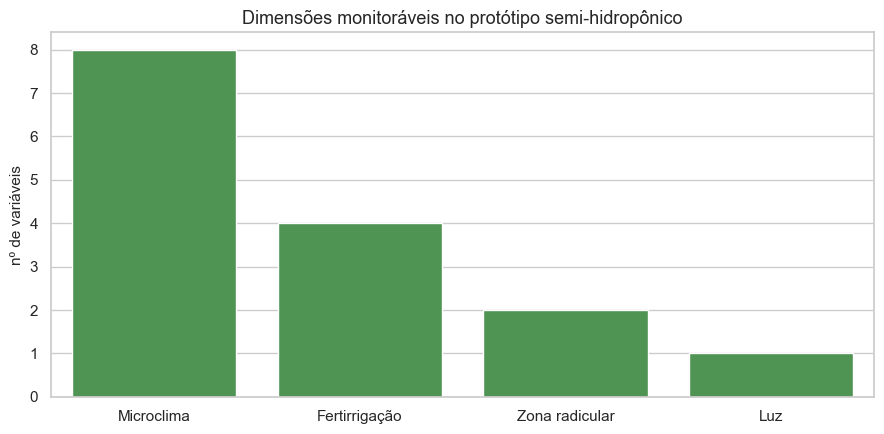

In [20]:
grupos = pd.DataFrame({
    'grupo': ['Microclima', 'Fertirrigação', 'Zona radicular', 'Luz'],
    'sensores/proxies na base': [8, 4, 2, 1],
    'exemplos': [
        'temperatura, UR, chuva, horas críticas',
        'pH, N, P, K',
        'temperatura e umidade do substrato',
        'luminosidade/PAR'
    ],
    'ação possível': [
        'ventilar, sombrear, proteger',
        'corrigir solução e pulsos',
        'irrigar, drenar, ajustar frequência',
        'sombrear/registrar radiação'
    ]
})
display(grupos)

fig, ax = plt.subplots(figsize=(9,4.5))
sns.barplot(data=grupos, x='grupo', y='sensores/proxies na base', color='#43a047', ax=ax)
ax.set(title='Dimensões monitoráveis no protótipo semi-hidropônico', xlabel='', ylabel='nº de variáveis')
plt.tight_layout(); salvar_grafico('10_dimensoes_monitoraveis', fig); plt.show()

### 12.1 Por que o sistema é viável para o AgroLab AI

O argumento sustentado por esta base é de **controlabilidade**:

- o substrato separa a zona radicular do solo local e permite fertirrigação frequente;
- pH e nutrientes podem ser medidos e corrigidos com menor atraso operacional;
- bancadas e ambiente protegido facilitam instalação, manutenção e leitura dos sensores;
- o histórico de microclima, solução e ações cria rastreabilidade para modelos futuros;
- alertas podem ser convertidos em ações concretas: irrigar, bloquear pulsos ou proteger.

Publicações brasileiras descrevem bom desempenho de `San Andreas` em cultivo fora do solo e resultados agronômicos favoráveis em sistema semi-hidropônico. Isso dá **plausibilidade externa** ao recorte; os gráficos deste notebook, isoladamente, não medem produtividade nem comparam custos.

### 12.2 O que ainda seria necessário para comparar com cultivo no solo

Uma comparação causal exige tratamentos contemporâneos e equivalentes:

| Requisito | Por quê |
|---|---|
| Mesma cultivar e origem das mudas | controla genética e qualidade inicial |
| Mesma região, janela e proteção | controla clima e pressão de doenças |
| Replicação e aleatorização | permite inferência e incerteza |
| Água, fertilizantes, energia e mão de obra | mede eficiência e custo total |
| Produção comercial, descarte, firmeza e °Brix | mede resultado agronômico real |
| Registro de pragas/doenças | avalia uma vantagem central do cultivo protegido |

Sem isso, a conclusão correta é: **o semi-hidropônico é uma plataforma mais instrumentável para este protótipo**, e não “produz mais” por definição.

## Parte 13 — Limitações, riscos e plano de validação

### Limitações atuais

1. Apenas 365 observações diárias sintéticas.
2. Série anual construída por sazonalidade, não por um ano completo observado.
3. Rótulos derivados de regras, sem validação cega por agrônomo.
4. Ausência de CE, vazão, volume drenado, drenagem, oxigênio dissolvido e fase fenológica.
5. Ausência de produtividade, qualidade do fruto, doença e custo.
6. `N`, `P` e `K` simulados isoladamente; em campo, sensores iônicos acessíveis e estáveis podem ser uma restrição técnica/econômica.
7. Recorte varietal informado na documentação, mas não observado como coluna experimental.

### Próximo desenho recomendado

- registrar leituras em frequência subdiária e guardar calibração/manutenção;
- adicionar CE de entrada/drenagem, vazão, drenagem %, fase fenológica e intervenção aplicada;
- pedir a um especialista que rotule uma amostra sem ver a regra do gerador;
- testar em bloco temporal futuro e depois em outro ciclo;
- medir falsos negativos das classes críticas separadamente;
- acompanhar produção comercial, descarte, °Brix, firmeza, água, fertilizante, energia e horas de trabalho.

## Parte 14 — Síntese para a tese/artigo

| # | Achado | Força da evidência |
|---|---|---|
| 1 | A base está íntegra e respeita checagens físicas básicas | direta, sobre o CSV |
| 2 | Há cobertura de estados ideais e de intervenção | direta, sobre o simulador |
| 3 | Relações de ar–substrato e luz aparecem de forma coerente | interna ao gerador |
| 4 | As ações apresentam sinal separável e aprendível | baseline, sem validade de campo |
| 5 | O sistema oferece múltiplas alavancas observáveis e acionáveis | estrutural/conceitual |
| 6 | `San Andreas` é um estudo de caso plausível no Brasil | literatura externa |
| 7 | Não há evidência para afirmar superioridade produtiva ou econômica | limitação explícita |

### Formulação defensável da conclusão

> A EDA mostra que o dataset sintético de morango é internamente consistente, cobre situações operacionais relevantes e contém sinal suficiente para que um classificador recupere as regras de manejo. Para o AgroLab AI, o cultivo protegido semi-hidropônico de morango `San Andreas` constitui um estudo de caso tecnicamente pertinente por combinar sensibilidade do cultivo com variáveis de microclima, fertirrigação e substrato passíveis de monitoramento e intervenção. Esses resultados validam o protótipo computacional e orientam a instrumentação, mas não demonstram, sem ensaio de campo comparativo, ganho causal de produtividade, qualidade ou rentabilidade.

## Referências essenciais

- SILVA, L. R. et al. Agronomic characteristics and postharvest quality of strawberry cultivars in a semi-hydroponic system. *Pesquisa Agropecuária Brasileira*, v. 59, e03384, 2024. https://doi.org/10.1590/S1678-3921.pab2024.v59.03384
- GIMÉNEZ, G. et al. *Produção de morango fora do solo*. Embrapa Clima Temperado, Documentos 410, 2015. https://www.infoteca.cnptia.embrapa.br/infoteca/bitstream/doc/1048342/1/Documento410.pdf
- VALMORBIDA, J. et al. Morango. In: EPAGRI. *Avaliação de cultivares para o Estado de Santa Catarina 2023–2024*, 2023.
- JONES, J. W. et al. The DSSAT cropping system model. *European Journal of Agronomy*, v. 18, p. 235–265, 2003. https://doi.org/10.1016/S1161-0301(02)00107-7
- XU, L. et al. Modeling tabular data using conditional GAN. *NeurIPS*, 2019. https://proceedings.neurips.cc/paper/2019/hash/254ed7d2de3b23ab10936522dd547b78-Abstract.html

> Antes da versão final do artigo, confira edição, autoria e padrão bibliográfico exigido pela instituição. Os limites operacionais do simulador também devem ser validados com orientação agronômica local.